# MRP3SAT Reduction

A quick prototype in Python to assess the feasibility of our Unity project.

## Important Assessments

- validate MRP3SAT instances
- given a valid instance, find a valid drawing
- align that drawing to a square and triangle grid
- convert that drawing to planar vertex cover on a triangle grid
- convert to a Bloons TD instance that can be played in Unity

## How To Run

From `python-prototype/`:

```bash
source venv/bin/activate
pip install -r requirements.txt
jupyter notebook mrp3sat_reduction.ipynb
```

Or, without activating the venv:

```bash
venv/bin/python -m pip install -r requirements.txt
venv/bin/jupyter notebook mrp3sat_reduction.ipynb
```

In VS Code, select the interpreter/kernel from `python-prototype/venv` and run cells top to bottom.

In [17]:
from __future__ import annotations

import os
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import yaml

%matplotlib inline

print("All OK!")

INPUT_PATH="input-simple.yaml"
CERT = {1: True, 2: True, 3: False}

All OK!


## Validate Problem Instances

In [18]:
@dataclass(frozen=True)
class Clause:
    label: str
    variables: tuple[int, int, int]
    sign: str

    @property
    def left(self) -> int:
        return min(self.variables)

    @property
    def right(self) -> int:
        return max(self.variables)


@dataclass(frozen=True)
class MRP3SATInstance:
    n: int
    m: int
    positive: tuple[Clause, ...]
    negative: tuple[Clause, ...]

    @property
    def clauses(self) -> tuple[Clause, ...]:
        return self.positive + self.negative


class ValidationError(Exception):
    """Raised when the input is not a valid MRP3SAT instance."""


def load_instance(path: Path | str) -> MRP3SATInstance:
    path = Path(path)
    try:
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle)
    except FileNotFoundError as exc:
        raise ValidationError(f"Input file not found: {path}") from exc
    except yaml.YAMLError as exc:
        raise ValidationError(f"YAML parse error: {exc}") from exc

    return parse_instance_data(data)


def parse_instance_data(data: object) -> MRP3SATInstance:
    if not isinstance(data, dict):
        raise ValidationError("Top-level YAML value must be a mapping.")
    raw_instance = data.get("instance")
    if not isinstance(raw_instance, dict):
        raise ValidationError("Missing required mapping: instance.")

    n = _required_int(raw_instance, "n")
    m = _required_int(raw_instance, "m")
    if n <= 0:
        raise ValidationError("instance.n must be a positive integer.")
    if m < 0:
        raise ValidationError("instance.m must be a nonnegative integer.")

    raw_positive = _required_clause_list(raw_instance, "positive")
    raw_negative = _required_clause_list(raw_instance, "negative")
    if len(raw_positive) + len(raw_negative) != m:
        raise ValidationError(
            "instance.m must equal len(instance.positive) + len(instance.negative)."
        )

    positive = tuple(
        _parse_clause(raw_clause, f"C{index}", "positive", n)
        for index, raw_clause in enumerate(raw_positive, start=1)
    )
    negative = tuple(
        _parse_clause(raw_clause, f"C{index}", "negative", n)
        for index, raw_clause in enumerate(raw_negative, start=len(positive) + 1)
    )

    return MRP3SATInstance(n=n, m=m, positive=positive, negative=negative)


def _required_int(mapping: dict, key: str) -> int:
    value = mapping.get(key)
    if type(value) is not int:
        raise ValidationError(f"instance.{key} must be an integer.")
    return value


def _required_clause_list(mapping: dict, key: str) -> list:
    value = mapping.get(key)
    if not isinstance(value, list):
        raise ValidationError(f"instance.{key} must be a list of clauses.")
    return value


def _parse_clause(raw_clause: object, label: str, sign: str, n: int) -> Clause:
    if not isinstance(raw_clause, list):
        raise ValidationError(f"{label} must be a list of exactly 3 variable IDs.")
    if len(raw_clause) != 3:
        raise ValidationError(f"{label} must contain exactly 3 variables.")
    if any(type(variable) is not int for variable in raw_clause):
        raise ValidationError(f"{label} must contain only integer variable IDs.")

    variables = tuple(raw_clause)
    if len(set(variables)) != 3:
        raise ValidationError(f"{label} must contain 3 distinct variables.")
    out_of_range = [variable for variable in variables if variable < 1 or variable > n]
    if out_of_range:
        bad = ", ".join(str(variable) for variable in out_of_range)
        raise ValidationError(f"{label} contains variable IDs outside 1..{n}: {bad}.")

    return Clause(label=label, variables=variables, sign=sign)


def compute_clause_levels(clauses: Iterable[Clause], side_name: str) -> dict[str, int]:
    clauses = tuple(clauses)
    by_label = {clause.label: clause for clause in clauses}
    edges: dict[str, set[str]] = {clause.label: set() for clause in clauses}
    indegree = {clause.label: 0 for clause in clauses}

    for outer in clauses:
        outer_variables = set(outer.variables)
        for inner in clauses:
            if outer == inner:
                continue
            has_blocked_connection = any(
                outer.left < variable < outer.right and variable not in outer_variables
                for variable in inner.variables
            )
            if not has_blocked_connection:
                continue
            if outer.label not in edges[inner.label]:
                edges[inner.label].add(outer.label)
                indegree[outer.label] += 1

    queue = deque(
        sorted(
            (label for label, degree in indegree.items() if degree == 0),
            key=_label_number,
        )
    )
    order: list[str] = []
    while queue:
        label = queue.popleft()
        order.append(label)
        for neighbor in sorted(edges[label], key=_label_number):
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                queue.append(neighbor)

    if len(order) != len(clauses):
        cyclic = ", ".join(
            sorted((label for label, degree in indegree.items() if degree > 0), key=_label_number)
        )
        raise ValidationError(
            f"{side_name} clauses cannot be drawn without crossings; "
            f"ordering constraints contain a cycle involving: {cyclic}."
        )

    return {label: level for level, label in enumerate(order, start=1) if label in by_label}


def _label_number(label: str) -> int:
    return int(label[1:])


def validate_instance(mrp3sat_instance: MRP3SATInstance) -> tuple[dict[str, int], dict[str, int]]:
    positive_levels = compute_clause_levels(mrp3sat_instance.positive, "Positive")
    negative_levels = compute_clause_levels(mrp3sat_instance.negative, "Negative")
    return positive_levels, negative_levels


def summarize_instance(mrp3sat_instance: MRP3SATInstance) -> None:
    print(
        f"Valid MRP3SAT instance: {mrp3sat_instance.n} variables, "
        f"{mrp3sat_instance.m} clauses ({len(mrp3sat_instance.positive)} positive, "
        f"{len(mrp3sat_instance.negative)} negative)."
    )
    for clause in mrp3sat_instance.clauses:
        literal_prefix = "" if clause.sign == "positive" else "not "
        literals = ", ".join(f"{literal_prefix}x{variable}" for variable in clause.variables)
        print(f"{clause.label}: {literals}")

In [19]:
input_path = Path(INPUT_PATH)
if not input_path.exists():
    input_path = Path("python-prototype/" + INPUT_PATH)

mrp3sat_instance = load_instance(input_path)
positive_levels, negative_levels = validate_instance(mrp3sat_instance)
summarize_instance(mrp3sat_instance)
print("Positive levels:", positive_levels)
print("Negative levels:", negative_levels)

Valid MRP3SAT instance: 3 variables, 1 clauses (1 positive, 0 negative).
C1: x1, x2, x3
Positive levels: {'C1': 1}
Negative levels: {}


## Find a valid drawing

In [20]:
# CONSTANTS
_BOX_H = 0.36
_GAP = 0  # integer units between variable boxes
_XAXIS_COLOUR = "#32cd32"
_POS_COLOUR = "#2166ac"
_NEG_COLOUR = "#b2182b"

In [21]:
def _build_queues(clauses: Iterable[Clause], levels: dict[str, int]) -> dict[int, list[Clause]]:
    '''
    I came up with this greedy algorithm! Why is it formally correct? Idk, intuition.
    (Claude wrote the code though)
    -- farms4life2016
    '''
    clauses = tuple(clauses)
    sorted_clauses = sorted(clauses, key=lambda c: (levels[c.label], _label_number(c.label)))

    all_vars: set[int] = set()
    for clause in clauses:
        all_vars.update(clause.variables)

    lefty:  dict[int, list[Clause]] = {v: [] for v in all_vars}
    middle: dict[int, list[Clause]] = {v: [] for v in all_vars}
    righty: dict[int, list[Clause]] = {v: [] for v in all_vars}

    for clause in sorted_clauses:
        L, M, R = sorted(clause.variables)
        righty[L].insert(0, clause)
        middle[M].append(clause)
        lefty[R].append(clause)

    return {v: lefty[v] + middle[v] + righty[v] for v in all_vars}


def _positions_from_queues(
    queues: dict[int, list[Clause]],
    x_start: dict[int, int],
) -> dict[tuple[str, int], int]:
    positions: dict[tuple[str, int], int] = {}
    for v, q in queues.items():
        for index, clause in enumerate(q):
            positions[(clause.label, v)] = x_start[v] + index
    return positions


def compute_layout(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(mrp3sat_instance.positive, positive_levels)
    neg_queues = _build_queues(mrp3sat_instance.negative, negative_levels)

    width: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, mrp3sat_instance.n + 1)
    }

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, mrp3sat_instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    pos_cx = _positions_from_queues(pos_queues, x_start)
    neg_cx = _positions_from_queues(neg_queues, x_start)

    return x_start, width, pos_cx, neg_cx

def _draw_side(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
    y_scale: float = 1.0
) -> None:
    for clause in clauses:
        y = direction * y_scale * levels[clause.label]
        xs = [connector_x[(clause.label, v)] for v in clause.variables]
        axis.plot([min(xs), max(xs)], [y, y], color=color, linewidth=2.4)
        y_root = direction * _BOX_H / 2
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            axis.plot([x, x], [y_root, y], color=color, linewidth=1.2, alpha=0.8)
            axis.scatter([x], [y], color=color, s=18, zorder=3)
        label_y = y + 0.16 * direction
        va = "bottom" if direction > 0 else "top"
        axis.text(
            (min(xs) + max(xs)) / 2, label_y, clause.label,
            ha="center", va=va, fontsize=10, color=color, fontweight="bold",
        )

def draw_instance(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start, width, pos_cx, neg_cx = compute_layout(mrp3sat_instance, positive_levels, negative_levels)

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x = max(x_start[v] + width[v] for v in range(1, mrp3sat_instance.n + 1))

    fig_width = max(7.0, total_x * 0.5)
    fig_height = max(4.5, (max_positive + max_negative + 2) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    # x-axis
    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, mrp3sat_instance.n + 1):
        bx = x_start[v] - 0.4
        bw = width[v] - 1 + 0.8   # connector columns are 0..width-1; pad ±0.4
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(
            bx + bw / 2, 0, f"x{v}",
            ha="center", va="center", fontsize=9, zorder=6,
        )

    _draw_side(axis, mrp3sat_instance.positive, positive_levels, pos_cx, direction=1,  color=_POS_COLOUR)
    _draw_side(axis, mrp3sat_instance.negative, negative_levels, neg_cx, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-1, total_x)
    axis.set_ylim(-(max_negative + 1), max_positive + 1)
    axis.set_xticks(range(total_x + 1))
    axis.set_yticks(range(-(max_negative + 1), max_positive + 2))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)
    axis.set_title("Square-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis



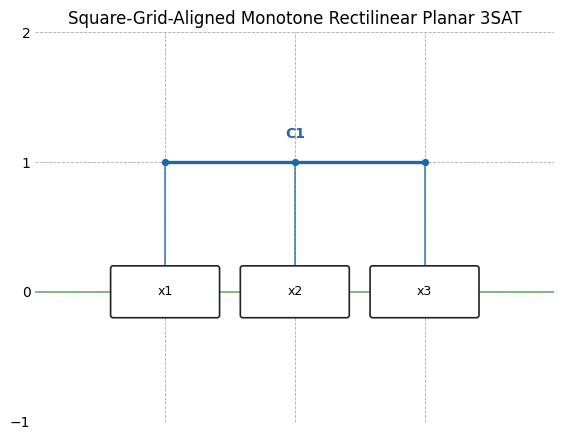

In [22]:
fig_mrp3sat, axis_mrp3sat = draw_instance(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

## Simple Transformations

In [23]:
import math

# MORE CONSTANTS
_SQRT3 = math.sqrt(3)
_GRID_STEP = _SQRT3 / 2


In [24]:
def compute_layout_alternating(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(mrp3sat_instance.positive, positive_levels)
    neg_queues = _build_queues(mrp3sat_instance.negative, negative_levels)

    # Each variable gets paired (up, down) slots; width = 2 * max occupancy
    slot_count: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, mrp3sat_instance.n + 1)
    }
    width: dict[int, int] = {v: 2 * slot_count[v] for v in range(1, mrp3sat_instance.n + 1)}

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, mrp3sat_instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    # Even columns go up (positive), odd columns go down (negative)
    pos_cx: dict[tuple[str, int], int] = {}
    for v, q in pos_queues.items():
        for i, clause in enumerate(q):
            pos_cx[(clause.label, v)] = x_start[v] + 2 * i

    neg_cx: dict[tuple[str, int], int] = {}
    for v, q in neg_queues.items():
        for i, clause in enumerate(q):
            neg_cx[(clause.label, v)] = x_start[v] + 2 * i + 1

    return x_start, width, pos_cx, neg_cx


def _fmt_sqrt3_half(k: int) -> str:
    """Format k * (√3/2) as a mathtext label."""
    if k == 0:
        return r"$0$"
    sign = "-" if k < 0 else ""
    a = abs(k)
    if a % 2 == 0:
        m = a // 2
        base = r"\sqrt{3}" if m == 1 else rf"{m}\sqrt{{3}}"
    else:
        base = r"\frac{\sqrt{3}}{2}" if a == 1 else rf"\frac{{{a}\sqrt{{3}}}}{{2}}"
    return rf"${sign}{base}$"


def draw_instance_alternating(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        mrp3sat_instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt = max(x_start_alt[v] + width_alt[v] for v in range(1, mrp3sat_instance.n + 1))

    k_min = -(2 * max_negative + 1)
    k_max =   2 * max_positive  + 1
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP

    fig_width = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, mrp3sat_instance.n + 1):
        bx = x_start_alt[v] - 0.4
        bw = width_alt[v] - 1 + 0.8
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(bx + bw / 2, 0, f"x{v}", ha="center", va="center", fontsize=9, zorder=6)

    _draw_side(axis, mrp3sat_instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR, y_scale=_SQRT3)
    _draw_side(axis, mrp3sat_instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR, y_scale=_SQRT3)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-1, total_x_alt)
    axis.set_ylim(y_bot, y_top)

    # x: integer gridlines, no labels
    axis.set_xticks(range(total_x_alt + 1))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)

    # left y-axis: every √3/2
    ytick_positions = [k * _GRID_STEP for k in range(k_min, k_max + 1)]
    ytick_labels    = [_fmt_sqrt3_half(k) for k in range(k_min, k_max + 1)]
    axis.set_yticks(ytick_positions)
    axis.set_yticklabels(ytick_labels, fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)

    axis.set_title(r"Alternating Square-Grid-Aligned Monotone Rectilinear Planar 3SAT (Vertically Scaled by $\sqrt{3}$)")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

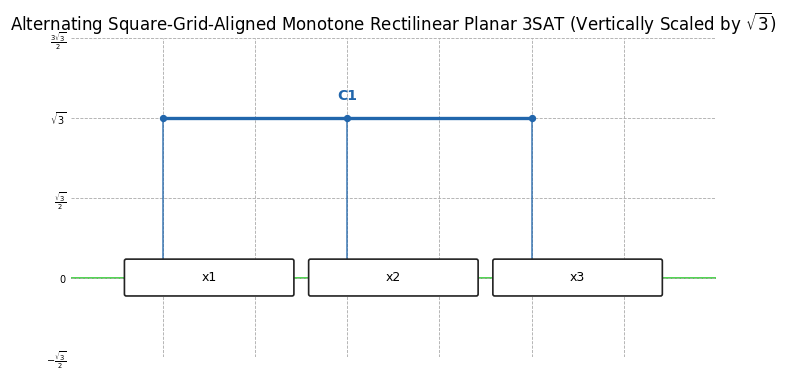

In [25]:
fig_alt, axis_alt = draw_instance_alternating(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

## Triangle Grid

In [26]:
# more constants
_ZIG = 0.5  # x-offset at odd half-step rows (defines the triangular grid)

In [27]:
def _zigzag_path(x: int, level: int, direction: int) -> tuple[list[float], list[float]]:
    """
    Path from (x, 0) to (x, direction * level * √3) along the triangular grid.
    Each level = 2 half-steps; odd half-steps shift x right by _ZIG.
    """
    n_steps = 2 * level
    xs = [x + (_ZIG if k % 2 == 1 else 0.0) for k in range(n_steps + 1)]
    ys = [direction * k * _GRID_STEP for k in range(n_steps + 1)]
    return xs, ys


def _draw_triangle_grid(
    axis,
    x_min: float,
    x_max: float,
    k_min: int,
    k_max: int,
    color: str = "#aaaaaa",
    linewidth: float = 0.6,
    linestyle: str = "--",
) -> None:
    """
    Three families of lines forming the triangular grid:
      Family 1 — horizontal:  y = k * _GRID_STEP
      Family 2 — slope +√3:   x = a + k/2   (integer a)
      Family 3 — slope −√3:   x = b − k/2   (integer b)
    All arithmetic is integer or integer/2, so no FP accumulation.
    """
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    kw = dict(color=color, linewidth=linewidth, linestyle=linestyle, zorder=0)

    for k in range(k_min, k_max + 1):
        axis.axhline(k * _GRID_STEP, **kw)

    # visible range: a + k/2 ∈ [x_min, x_max] for some k ∈ [k_min, k_max]
    a_min = math.floor(x_min - k_max / 2) - 1
    a_max = math.ceil( x_max - k_min / 2) + 1
    for a in range(a_min, a_max + 1):
        axis.plot([a + k_min / 2, a + k_max / 2], [y_bot, y_top], **kw)

    # visible range: b - k/2 ∈ [x_min, x_max] for some k ∈ [k_min, k_max]
    b_min = math.floor(x_min + k_min / 2) - 1
    b_max = math.ceil( x_max + k_max / 2) + 1
    for b in range(b_min, b_max + 1):
        axis.plot([b - k_min / 2, b - k_max / 2], [y_bot, y_top], **kw)


def _draw_side_triangle(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> None:
    for clause in clauses:
        level = levels[clause.label]
        y = direction * level * _SQRT3
        xs = [connector_x[(clause.label, v)] for v in clause.variables]

        axis.plot([min(xs), max(xs)], [y, y], color=color, linewidth=2.4, zorder=3)
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            zx, zy = _zigzag_path(x, level, direction)
            axis.plot(zx, zy, color=color, linewidth=1.2, alpha=0.8, zorder=2)
            axis.scatter([x], [y], color=color, s=18, zorder=4)

        label_y = y + 0.16 * direction
        va = "bottom" if direction > 0 else "top"
        axis.text(
            (min(xs) + max(xs)) / 2, label_y, clause.label,
            ha="center", va=va, fontsize=10, color=color, fontweight="bold", zorder=4,
        )


def draw_instance_triangle(
    instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min  = -(2 * max_negative + 1)
    k_max  =   2 * max_positive  + 1
    y_bot  = k_min * _GRID_STEP
    y_top  = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start_alt[v] - 0.4
        bw = width_alt[v] - 1 + 0.8
        axis.add_patch(FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        ))
        axis.text(bx + bw / 2, 0, f"x{v}", ha="center", va="center", fontsize=9, zorder=6)

    _draw_side_triangle(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    _draw_side_triangle(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangular-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

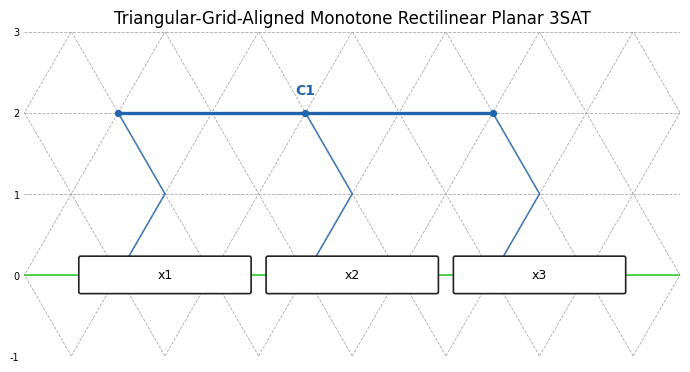

In [28]:
fig_tri, axis_tri = draw_instance_triangle(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

## Vertex Cover Conversion

In [29]:
_NODE_R_VAR    = 55    # scatter s= for variable-gadget nodes
_NODE_R_CLAUSE = 40    # scatter s= for clause-gadget (triangle) nodes

In [30]:
# ALL DRAWING FUNCTIONS MUST RETURN A NODE COUNT OF DRAWN COMPONENTS!!!

def _draw_variable_gadgets_vc(
    axis,
    instance: MRP3SATInstance,
    x_start: dict[int, int],
    width: dict[int, int],
) -> int:
    nc = 0
    for v in range(1, instance.n + 1):
        x0 = x_start[v]
        w  = width[v]
        # one edge per adjacent pair
        for i in range(w - 1):
            axis.plot([x0 + i, x0 + i + 1], [0, 0],
                      color="#444444", linewidth=1.2, zorder=2)
        # nodes: even offset from x0 = true (filled), odd = false (hollow)
        for i in range(w):
            x = x0 + i
            if i % 2 == 0:
                axis.scatter([x], [0], s=_NODE_R_VAR, color="#222222",
                             linewidths=1.2, zorder=6)
            else:
                axis.scatter([x], [0], s=_NODE_R_VAR, facecolors="white",
                             edgecolors="#222222", linewidths=1.2, zorder=6)
            nc = nc + 1
        # variable label below the chain
        axis.text(x0 + (w - 1) / 2, -0.28, f"x{v}",
                  ha="center", va="top", fontsize=8, color="#333333")
    # count number of pts we plotted
    return nc


def _draw_or_gadget(
    axis,
    x_M: int,
    y: float,
    direction: int,
    color: str,
    x_L: int,
    x_R: int,
) -> int:
    A  = (float(x_M), y)
    B  = (x_M - 0.5,  y + direction * _GRID_STEP)
    C  = (x_M + 0.5,  y + direction * _GRID_STEP)
    jl = x_M - 1
    jr = x_M + 1

    kw = dict(color=color, linewidth=1.5, zorder=2)

    # clause bar: left and right segments around the gadget
    axis.plot([x_L, jl], [y, y], **kw)
    axis.plot([jr,  x_R], [y, y], **kw)

    # junction → triangle apex nodes (unit-length grid edges)
    axis.plot([jl, B[0]], [y, B[1]], **kw)
    axis.plot([jr, C[0]], [y, C[1]], **kw)

    # triangle edges A-B, A-C, B-C (all unit-length)
    axis.plot([A[0], B[0]], [A[1], B[1]], **kw)
    axis.plot([A[0], C[0]], [A[1], C[1]], **kw)
    axis.plot([B[0], C[0]], [B[1], C[1]], **kw)

    # triangle nodes
    for pt in (A, B, C):
        if (pt[1] < 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, color=color, linewidths=1.2, zorder=5)
        elif (pt[1] > 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, facecolors="white", edgecolors=color, linewidths=1.2, zorder=5)
    # triangle has 3 nodes
    return 3


def _draw_side_vc(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> int:
    nc = 0
    for clause in clauses:
        level    = levels[clause.label]
        y        = direction * level * _SQRT3
        L, M, R  = sorted(clause.variables)
        x_L = connector_x[(clause.label, L)]
        x_M = connector_x[(clause.label, M)]
        x_R = connector_x[(clause.label, R)]

        # zigzag connectors from variable gadget to clause bar
        # (intermediate subdivision nodes omitted for now — improve iteratively)
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            zx, zy = _zigzag_path(x, level, direction)
            axis.plot(zx, zy, color=color, linewidth=1.2, alpha=0.8, zorder=2)

        nc = nc + _draw_or_gadget(axis, x_M, y, direction, color, x_L, x_R)

        # label just beyond the triangle apex row
        apex_y  = y + direction * _GRID_STEP
        label_y = apex_y + direction * 0.16
        va = "bottom" if direction > 0 else "top"
        axis.text(x_M, label_y, clause.label, ha="center", va=va, fontsize=10, color=color, fontweight="bold", zorder=4)

    # return sum of nodes (or len(clauses) * 3)
    return nc


def draw_instance_vertex_cover(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    nc = 0
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        mrp3sat_instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, mrp3sat_instance.n + 1))

    # +1 for clause bar row, +1 for triangle apex row (beyond draw_instance_triangle's range)
    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    nc = nc + _draw_variable_gadgets_vc(axis, mrp3sat_instance, x_start_alt, width_alt)
    nc = nc + _draw_side_vc(axis, mrp3sat_instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    nc = nc + _draw_side_vc(axis, mrp3sat_instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangle-Grid-Aligned Planar Vertex Cover with Max Degree 3")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis, nc

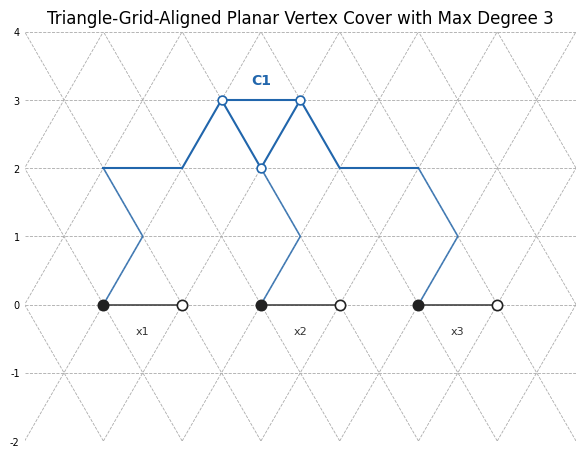

In [31]:
fig_vc, axis_vc, node_count = draw_instance_vertex_cover(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

In [32]:
# value of k that makes the problem instance NP-complete
# 2 * m + (number of non-clause nodes / 2)
print("[DEBUG] node count is", node_count)
non_clause_nodes = node_count - 3 * mrp3sat_instance.m
print("k = 2m + non_clause_nodes/2 =", 2 * mrp3sat_instance.m + int(non_clause_nodes/2))
# ideally render this in LaTeX

[DEBUG] node count is 9
k = 2m + non_clause_nodes/2 = 5


## Triangle-Grid-Embedding

In [33]:
_NODE_R_CONNECT = 22

In [34]:
# ALL DRAWING FUNCTIONS MUST RETURN A NODE COUNT OF DRAWN COMPONENTS!!!

# this is literally the same logic as _draw_or_gadget
# **except** pt[1] > 0 and pt[1] < 0 are swapped in the if-elif
def _draw_or_gadget_embedding(
    axis,
    x_M: int,
    y: float,
    direction: int,
    color: str,
    x_L: int,
    x_R: int,
) -> int:
    A  = (float(x_M), y)
    B  = (x_M - 0.5,  y + direction * _GRID_STEP)
    C  = (x_M + 0.5,  y + direction * _GRID_STEP)
    jl = x_M - 1
    jr = x_M + 1

    kw = dict(color=color, linewidth=1.5, zorder=2)

    # clause bar: left and right segments around the gadget
    axis.plot([x_L, jl], [y, y], **kw)
    axis.plot([jr,  x_R], [y, y], **kw)

    # junction → triangle apex nodes (unit-length grid edges)
    axis.plot([jl, B[0]], [y, B[1]], **kw)
    axis.plot([jr, C[0]], [y, C[1]], **kw)

    # triangle edges A-B, A-C, B-C (all unit-length)
    axis.plot([A[0], B[0]], [A[1], B[1]], **kw)
    axis.plot([A[0], C[0]], [A[1], C[1]], **kw)
    axis.plot([B[0], C[0]], [B[1], C[1]], **kw)

    # triangle nodes
    for pt in (A, B, C):
        if (pt[1] > 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, color=color, linewidths=1.2, zorder=5)
        elif (pt[1] < 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, facecolors="white", edgecolors=color, linewidths=1.2, zorder=5)
    # triangle = 3 pts
    return 3



def _draw_bipartite_vertex(
    axis,
    x: float,
    y: float,
    parity: int,
    size: float = _NODE_R_CONNECT,
) -> int:
    """
    Draw a connector-gadget vertex using the global checkerboard
    2-colouring of the triangular lattice.

    parity = 0 -> filled
    parity = 1 -> hollow
    """
    draw_colour = _POS_COLOUR
    if (y < 0):
        draw_colour = _NEG_COLOUR

    if parity % 2 == 0:
        axis.scatter(
            [x], [y],
            s=size,
            color=draw_colour,
            linewidths=1.0,
            zorder=5,
        )
    else:
        axis.scatter(
            [x], [y],
            s=size,
            facecolors="white",
            edgecolors=draw_colour,
            linewidths=1.0,
            zorder=5,
        )
    # we drew 1 point
    return 1


def _triangle_grid_parity(x: float, y: float) -> int:
    """
    Bipartition of the triangular lattice.

    Parity can be determined based on x-coord:
    - even integer       -> filled
    - even integer + 0.5 -> hollow
    - odd integer        -> hollow
    - odd integer + 0.5  -> filled

    idk why this works, but the pattern works from observation...
    (and yes this is my algorithm lol)
    """

    FILLED = 0
    HOLLOW = 1

    # to avoid Floating point mess, use ints:
    # ceil of int = floor of same int
    # ceil of (int + 0.5) > floor of same (int + 0.5)
    floor = int(x)
    ceil = int(math.ceil(x))
    if (floor % 2 == 0):
        if (floor < ceil):
            return HOLLOW
        return FILLED
    else:
        if (floor < ceil):
            return FILLED
        return HOLLOW


def _draw_unit_path_vertices(
    axis,
    xs: list[float],
    ys: list[float],
) -> int:
    """
    Draw all interior vertices of a triangle-grid path.

    Endpoints are skipped because the caller typically draws
    those separately.
    """
    nc = 0

    for x, y in zip(xs[1:-1], ys[1:-1]):
        nc = nc + _draw_bipartite_vertex(
            axis,
            x,
            y,
            _triangle_grid_parity(x, y),
        )
    # could also calculate nc using len() and multiplication...
    return nc

In [35]:
def _draw_side_vc_embedding(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> int:

    nc = 0

    for clause in clauses:
        level = levels[clause.label]
        y     = direction * level * _SQRT3

        L, M, R = sorted(clause.variables)

        x_L = connector_x[(clause.label, L)]
        x_M = connector_x[(clause.label, M)]
        x_R = connector_x[(clause.label, R)]

        #
        # connector wires
        #
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]

            zx, zy = _zigzag_path(x, level, direction)

            axis.plot(
                zx,
                zy,
                color=color,
                linewidth=1.2,
                alpha=0.8,
                zorder=2,
            )

            nc = nc + _draw_unit_path_vertices(axis, zx, zy)

        #
        # clause-bar subdivision vertices
        #
        for x in range(x_L, x_M):
            nc = nc + _draw_bipartite_vertex(
                axis,
                x,
                y,
                _triangle_grid_parity(x, y),
            )

        for x in range(x_M + 1, x_R + 1):
            nc = nc + _draw_bipartite_vertex(
                axis,
                x,
                y,
                _triangle_grid_parity(x, y),
            )

        nc = nc + _draw_or_gadget_embedding(
            axis,
            x_M,
            y,
            direction,
            color,
            x_L,
            x_R,
        )

        apex_y  = y + direction * _GRID_STEP
        label_y = apex_y + direction * 0.16

        va = "bottom" if direction > 0 else "top"

        axis.text(
            x_M,
            label_y,
            clause.label,
            ha="center",
            va=va,
            fontsize=10,
            color=color,
            fontweight="bold",
            zorder=4,
        )

    # nc should be comprehensive
    return nc

In [36]:
def draw_instance_vertex_cover_embedding(
    instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:

    nc = 0
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    # +1 for clause bar row, +1 for triangle apex row (beyond draw_instance_triangle's range)
    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    nc = nc + _draw_variable_gadgets_vc(axis, instance, x_start_alt, width_alt)
    nc = nc + _draw_side_vc_embedding(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    nc = nc + _draw_side_vc_embedding(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangle-Grid-Embedded Planar Vertex Cover with Max Degree 3")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis, nc

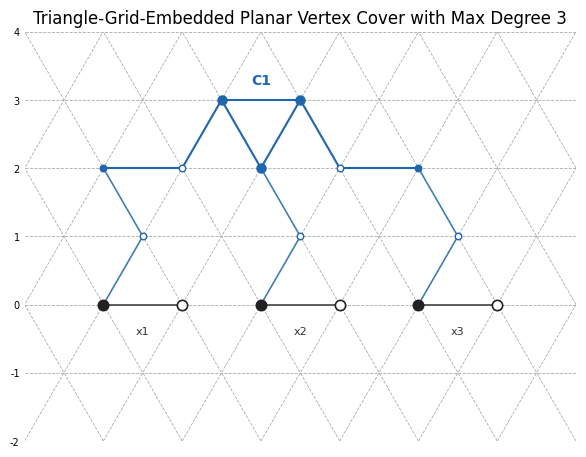

In [37]:
willthiswork, idkman, node_count_emb = draw_instance_vertex_cover_embedding(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

In [38]:
# value of k that makes the problem instance NP-complete
# 2 * m + (number of non-clause nodes / 2)
print("[DEBUG] node count is", node_count_emb) # nc should be 90 for input.yaml
non_clause_nodes_emb = node_count_emb - 3 * mrp3sat_instance.m
print("k = 2m + nodes/2 =", 2 * mrp3sat_instance.m + int(non_clause_nodes_emb/2))
# ideally render this in LaTeX

[DEBUG] node count is 16
k = 2m + nodes/2 = 8


## Bloon TD Range Visualization

In [39]:
import numpy as np
from PIL import Image as PILImage
from matplotlib.patches import Circle, Ellipse, RegularPolygon

_TOWER_RANGE       = 0.45      # tune between ~0.4 and 0.6 to see overlap behaviour
_RANGE_FILL        = "#00d4ff"
_RANGE_EDGE        = "#0099cc"
_RANGE_ALPHA       = 0.13

_ICON_HALF_MONKEY  = 0.22     # dart monkey icon half-size in data units
_ICON_HALF_BLOON   = 0.15     # red bloon icon half-size in data units

_DART_MONKEY_URL   = "BTD5_dart_monke.png"
_RED_BLOON_URL     = "BTD5_red_bloon.png"

_MONKEY_FILL       = "#8b6914"
_MONKEY_EDGE       = "#4a3800"
_BLOON_FILL        = "#ff2222"
_BLOON_EDGE        = "#990000"
_BLOON_HILITE      = "#ff9999"

In [40]:
_img_cache: dict[str, "np.ndarray | None"] = {}

def _load_square_rgba(path: str) -> np.ndarray:
    img = PILImage.open(path).convert("RGBA")

    w, h = img.size
    side = max(w, h)

    # transparent canvas
    square = PILImage.new("RGBA", (side, side), (0, 0, 0, 0))

    # centered placement
    x = (side - w) // 2
    y = (side - h) // 2

    square.paste(img, (x, y))

    return np.array(square)

def _try_load_img(path: str) -> "np.ndarray | None":
    if path not in _img_cache:
        try:
            _img_cache[path] = _load_square_rgba(path)
            print(f"[Bloons TD] loaded {path}")
        except Exception as exc:
            print(f"[Bloons TD] image unavailable ({exc}), using fallback")
            _img_cache[path] = None
    return _img_cache[path]


In [41]:

def _draw_icon(
    axis,
    x: float,
    y: float,
    url: str,
    fallback_fn,
    half: float,
) -> None:
    """Draw image centred at (x, y) in data coords, falling back to a patch."""
    img = _try_load_img(url)
    if img is not None:
        axis.imshow(
            img,
            extent=[x - half, x + half, y - half, y + half],
            aspect="auto",
            zorder=7,
            interpolation="antialiased",
        )
    else:
        fallback_fn(axis, x, y, half)


def _fallback_dart_monkey(axis, x: float, y: float, half: float) -> None:
    axis.add_patch(RegularPolygon(
        (x, y), numVertices=6, radius=half,
        orientation=math.pi / 6,
        facecolor=_MONKEY_FILL, edgecolor=_MONKEY_EDGE,
        linewidth=0.9, zorder=7,
    ))
    # tiny dart pointing right
    axis.annotate(
        "", xy=(x + half * 0.95, y), xytext=(x + half * 0.15, y),
        arrowprops=dict(arrowstyle="->", color="white", lw=0.8),
        zorder=8,
    )


def _fallback_red_bloon(axis, x: float, y: float, half: float) -> None:
    # oval body
    axis.add_patch(Ellipse(
        (x, y - half * 0.05), width=half * 1.7, height=half * 2.0,
        facecolor=_BLOON_FILL, edgecolor=_BLOON_EDGE,
        linewidth=0.7, zorder=7,
    ))
    # highlight
    axis.add_patch(Ellipse(
        (x - half * 0.3, y + half * 0.3), width=half * 0.5, height=half * 0.55,
        facecolor=_BLOON_HILITE, edgecolor="none", alpha=0.65, zorder=8,
    ))
    # knot
    axis.plot(
        [x, x], [y + half * 0.85, y + half * 1.1],
        color=_BLOON_EDGE, linewidth=0.7, zorder=8,
    )


def _collect_edges_vc_embedding(
    instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    x_start: dict[int, int],
    width: dict[int, int],
    pos_cx: dict[tuple[str, int], int],
    neg_cx: dict[tuple[str, int], int],
) -> list[tuple[tuple[float, float], tuple[float, float]]]:
    """Return every unit edge in the embedded VC graph as ((x1,y1),(x2,y2))."""
    edges: list[tuple[tuple[float, float], tuple[float, float]]] = []

    # Variable chain unit edges along y = 0
    for v in range(1, instance.n + 1):
        x0, w = x_start[v], width[v]
        for i in range(w - 1):
            edges.append(((float(x0 + i), 0.0), (float(x0 + i + 1), 0.0)))

    def _side(
        clauses: Iterable[Clause],
        levels: dict[str, int],
        connector_x: dict[tuple[str, int], int],
        direction: int,
    ) -> None:
        for clause in clauses:
            level = levels[clause.label]
            y     = direction * level * _SQRT3
            L, M, R = sorted(clause.variables)
            x_L = connector_x[(clause.label, L)]
            x_M = connector_x[(clause.label, M)]
            x_R = connector_x[(clause.label, R)]

            # Zigzag connectors (each step is already unit length)
            for v in sorted(clause.variables):
                cx = connector_x[(clause.label, v)]
                zx, zy = _zigzag_path(cx, level, direction)
                for i in range(len(zx) - 1):
                    edges.append(((zx[i], zy[i]), (zx[i + 1], zy[i + 1])))

            # Left bar unit edges: x_L .. x_M-1  (endpoint is jl)
            for x in range(x_L, x_M - 1):
                edges.append(((float(x), y), (float(x + 1), y)))

            # Right bar unit edges: x_M+1 .. x_R  (start is jr)
            for x in range(x_M + 1, x_R):
                edges.append(((float(x), y), (float(x + 1), y)))

            # OR gadget: two slanted junction edges + triangle
            A  = (float(x_M),      y)
            B  = (x_M - 0.5,  y + direction * _GRID_STEP)
            C  = (x_M + 0.5,  y + direction * _GRID_STEP)
            jl = (float(x_M - 1), y)
            jr = (float(x_M + 1), y)
            edges.extend([(jl, B), (jr, C), (A, B), (A, C), (B, C)])

    _side(instance.positive, positive_levels, pos_cx, 1)
    _side(instance.negative, negative_levels, neg_cx, -1)

    return edges


def draw_instance_btd_ranges(
    instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    edges = _collect_edges_vc_embedding(
        instance, positive_levels, negative_levels,
        x_start_alt, width_alt, pos_cx_alt, neg_cx_alt,
    )
    nodes = {pt for edge in edges for pt in edge}

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    # Faint triangle grid
    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max, color="#dddddd")

    # Graph edges in x-axis colour so edges are visible but not distracting
    for (x1, y1), (x2, y2) in edges:
        axis.plot([x1, x2], [y1, y2], color=_XAXIS_COLOUR, linewidth=3.0, zorder=1)

    # Tower ranges (drawn below nodes and bloons)
    # Note: adjacent nodes are 1 unit apart, so ranges touch at _TOWER_RANGE = 0.5
    # and overlap when _TOWER_RANGE > 0.5
    for (x, y) in nodes:
        axis.add_patch(Circle(
            (x, y), _TOWER_RANGE,
            facecolor=_RANGE_FILL, edgecolor=_RANGE_EDGE,
            linewidth=0.8, alpha=_RANGE_ALPHA, zorder=2,
        ))

    # Dart monkey on each node
    for (x, y) in nodes:
        _draw_icon(axis, x, y, _DART_MONKEY_URL, _fallback_dart_monkey, _ICON_HALF_MONKEY)

    # Red bloon at each edge midpoint
    for (x1, y1), (x2, y2) in edges:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        _draw_icon(axis, mx, my, _RED_BLOON_URL, _fallback_red_bloon, _ICON_HALF_BLOON)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Bloons TD Tower Range Visualization")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

[Bloons TD] loaded BTD5_dart_monke.png
[Bloons TD] loaded BTD5_red_bloon.png


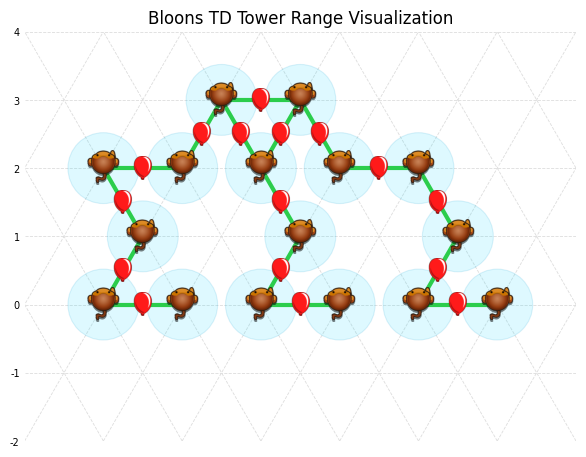

In [42]:
fig_btd_range, axis_btd_range = draw_instance_btd_ranges(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

## Bloons TD Track Length Visualization

In [43]:
_TRACK_FAST_COLOUR   = "#ff00ff"  # degree 1
_TRACK_MED_COLOUR    = "#16db65"  # degree 2
_TRACK_SLOW_COLOUR   = "#0d2818"  # degree 3
_TRACK_LINEWIDTH     = 3.0

In [44]:
def _compute_node_degrees(
    edges: list[tuple[tuple[float, float], tuple[float, float]]],
) -> dict[tuple[float, float], int]:
    degrees: dict[tuple[float, float], int] = {}
    for p1, p2 in edges:
        degrees[p1] = degrees.get(p1, 0) + 1
        degrees[p2] = degrees.get(p2, 0) + 1
    return degrees


def _degree_colour(degree: int) -> str:
    if degree == 1:
        return _TRACK_FAST_COLOUR
    elif degree == 2:
        return _TRACK_MED_COLOUR
    else:
        return _TRACK_SLOW_COLOUR


def draw_instance_btd(
    instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    edges = _collect_edges_vc_embedding(
        instance, positive_levels, negative_levels,
        x_start_alt, width_alt, pos_cx_alt, neg_cx_alt,
    )
    nodes       = {pt for edge in edges for pt in edge}
    node_degree = _compute_node_degrees(edges)

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max, color="#dddddd")

    # Each edge drawn as two half-segments, each coloured by the monkey on that end
    for p1, p2 in edges:
        x1, y1 = p1
        x2, y2 = p2
        mx, my  = (x1 + x2) / 2, (y1 + y2) / 2
        axis.plot([x1, mx], [y1, my],
                  color=_degree_colour(node_degree[p1]),
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")
        axis.plot([mx, x2], [my, y2],
                  color=_degree_colour(node_degree[p2]),
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")

    # Tower ranges
    for x, y in nodes:
        axis.add_patch(Circle(
            (x, y), _TOWER_RANGE,
            facecolor=_RANGE_FILL, edgecolor=_RANGE_EDGE,
            linewidth=0.8, alpha=_RANGE_ALPHA, zorder=2,
        ))

    # Dart monkey on each node
    for x, y in nodes:
        _draw_icon(axis, x, y, _DART_MONKEY_URL, _fallback_dart_monkey, _ICON_HALF_MONKEY)

    # Red bloon at each edge midpoint
    for p1, p2 in edges:
        x1, y1 = p1
        x2, y2 = p2
        _draw_icon(axis, (x1 + x2) / 2, (y1 + y2) / 2,
                   _RED_BLOON_URL, _fallback_red_bloon, _ICON_HALF_BLOON)

    # Legend
    for label, colour in [("fast (deg 1)", _TRACK_FAST_COLOUR),
                           ("medium (deg 2)", _TRACK_MED_COLOUR),
                           ("slow (deg 3)", _TRACK_SLOW_COLOUR)]:
        axis.plot([], [], color=colour, linewidth=2.5, label=label)
    axis.legend(loc="upper right", fontsize=7, framealpha=0.7)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)
    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])
    axis.set_title(r"Bloons TD Track Speed Visualization")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

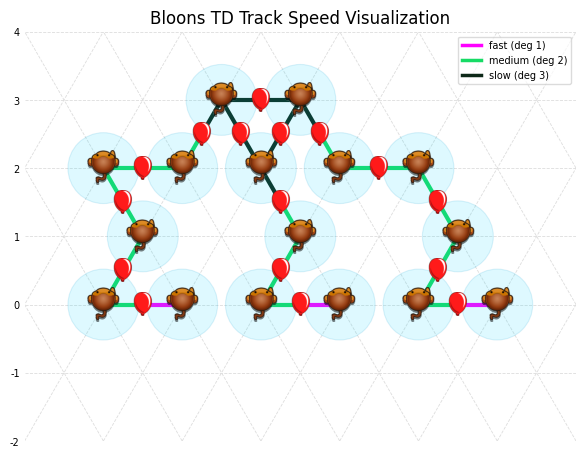

In [45]:
fig_btd_range, axis_btd_range = draw_instance_btd(mrp3sat_instance, positive_levels, negative_levels)
plt.show()

## Direct Conversion

In [46]:
# data structures

import json
from enum import Enum
from dataclasses import dataclass

class TrackSpeed(Enum):
    FAST   = 1   # in-degree 1
    MEDIUM = 2   # in-degree 2
    SLOW   = 3   # in-degree 3


@dataclass(frozen=True)
class GridPoint:
    """
    Integer coordinates on the triangular grid.
    Render by:   x = gp.gx * 0.5
                 y = gp.gy * (√3/2)
    Even gx → integer x.  Odd gx → half-integer x (zigzag and OR-gadget apices).
    """
    gx: int
    gy: int


@dataclass(frozen=True)
class BtdEdge:
    """
    One unit-length bloon track segment.
    start_speed / end_speed are the track speeds on each half-segment,
    determined by the in-degree of the monkey at that endpoint.
    """
    start:       GridPoint
    end:         GridPoint
    start_speed: TrackSpeed
    end_speed:   TrackSpeed


@dataclass
class BtdInstance:
    """
    BTD tower-defense instance derived from MRP3SAT → Planar VC.

    vertices  — dart monkey positions; loop to place towers
    edges     — bloon track segments; loop to draw paths and spawn bloons
    k         — vertex cover target (monkeys needed to cover every track)
    adjacency — neighbour lists for solvers / verifiers (BFS, DFS, LP, etc.)

    Coordinate contract (identical for Unity, Godot, canvas, matplotlib):
        world_x = vertex.gx * 0.5
        world_y = vertex.gy * (√3/2)

    JSON export:  json.dumps(btd.to_dict())
    """
    vertices:  list[GridPoint]
    edges:     list[BtdEdge]
    k:         int
    adjacency: dict[GridPoint, list[GridPoint]]

    def to_dict(self) -> dict:
        def _gp(gp: GridPoint) -> dict:
            return {"gx": gp.gx, "gy": gp.gy}

        def _key(gp: GridPoint) -> str:
            return f"{gp.gx},{gp.gy}"

        return {
            "k":        self.k,
            "vertices": [_gp(v) for v in self.vertices],
            "edges": [
                {
                    "start":       _gp(e.start),
                    "end":         _gp(e.end),
                    "start_speed": e.start_speed.name,
                    "end_speed":   e.end_speed.name,
                }
                for e in self.edges
            ],
            "adjacency": {
                _key(v): [_gp(n) for n in nbrs]
                for v, nbrs in self.adjacency.items()
            },
        }

In [47]:
# instance mapping and rendering

def _collect_btd_raw_edges(
    mrp3sat_instance:         MRP3SATInstance,
    positive_levels:  dict[str, int],
    negative_levels:  dict[str, int],
    x_start:          dict[int, int],
    width:            dict[int, int],
    pos_cx:           dict[tuple[str, int], int],
    neg_cx:           dict[tuple[str, int], int],
) -> list[tuple[GridPoint, GridPoint]]:
    """
    Build the complete edge list in pure integer grid coordinates.

    gx encoding:  gx = float_x * 2   →  x = gx * 0.5
    gy encoding:  gy = row index k    →  y = gy * (√3/2)

    No floating-point arithmetic here; irrational constants are never touched.
    """
    raw: list[tuple[GridPoint, GridPoint]] = []

    # ── variable chain (y = 0, gy = 0) ──────────────────────────────────────
    for v in range(1, mrp3sat_instance.n + 1):
        x0, w = x_start[v], width[v]
        for i in range(w - 1):
            raw.append((
                GridPoint(gx=2*(x0 + i),     gy=0),
                GridPoint(gx=2*(x0 + i + 1), gy=0),
            ))

    def _add_clause_edges(
        clauses:     Iterable[Clause],
        levels:      dict[str, int],
        connector_x: dict[tuple[str, int], int],
        direction:   int,
    ) -> None:
        for clause in clauses:
            level = levels[clause.label]
            L, M, R = sorted(clause.variables)
            x_L = connector_x[(clause.label, L)]
            x_M = connector_x[(clause.label, M)]
            x_R = connector_x[(clause.label, R)]

            # gy of the clause bar:  y_clause = direction*level*√3
            #                                  = (direction*2*level) * (√3/2)
            gy_bar = direction * 2 * level

            # ── zigzag connectors ────────────────────────────────────────────
            # Odd steps shift gx by +1 (= +0.5 in float), encoding the
            # rightward zig of the triangular path.
            for v in sorted(clause.variables):
                cx = connector_x[(clause.label, v)]
                for step in range(2 * level):
                    gx1 = 2*cx + (1 if step       % 2 == 1 else 0)
                    gy1 = direction * step
                    gx2 = 2*cx + (1 if (step + 1) % 2 == 1 else 0)
                    gy2 = direction * (step + 1)
                    raw.append((GridPoint(gx1, gy1), GridPoint(gx2, gy2)))

            # ── clause bar (left of OR gadget) ───────────────────────────────
            # nodes: x_L, x_L+1, ..., x_M-1  →  edges between adjacent pairs
            for x in range(x_L, x_M - 1):
                raw.append((
                    GridPoint(gx=2*x,       gy=gy_bar),
                    GridPoint(gx=2*(x + 1), gy=gy_bar),
                ))

            # ── clause bar (right of OR gadget) ──────────────────────────────
            # nodes: x_M+1, x_M+2, ..., x_R
            for x in range(x_M + 1, x_R):
                raw.append((
                    GridPoint(gx=2*x,       gy=gy_bar),
                    GridPoint(gx=2*(x + 1), gy=gy_bar),
                ))

            # ── OR gadget ────────────────────────────────────────────────────
            # A  = (x_M,       gy_bar)         — M's zigzag endpoint / bottom apex
            # B  = (x_M - 0.5, gy_bar ± 1)    — upper-left  (odd gx)
            # C  = (x_M + 0.5, gy_bar ± 1)    — upper-right (odd gx)
            # jl = (x_M - 1,   gy_bar)         — left  bar endpoint
            # jr = (x_M + 1,   gy_bar)         — right bar endpoint
            jl = GridPoint(gx=2*(x_M - 1), gy=gy_bar)
            jr = GridPoint(gx=2*(x_M + 1), gy=gy_bar)
            A  = GridPoint(gx=2*x_M,       gy=gy_bar)
            B  = GridPoint(gx=2*x_M - 1,   gy=gy_bar + direction)
            C  = GridPoint(gx=2*x_M + 1,   gy=gy_bar + direction)

            raw.extend([(jl, B), (jr, C), (A, B), (A, C), (B, C)])

    _add_clause_edges(mrp3sat_instance.positive, positive_levels, pos_cx,  1)
    _add_clause_edges(mrp3sat_instance.negative, negative_levels, neg_cx, -1)
    return raw


def mrp3sat_to_btd(
    mrp3sat_instance:        MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> BtdInstance:
    """
    Direct MRP3SAT → BTD transformation.
    All intermediate steps stay in integers; no FP until draw time.
    """
    x_start, width, pos_cx, neg_cx = compute_layout_alternating(
        mrp3sat_instance, positive_levels, negative_levels
    )
    raw_edges = _collect_btd_raw_edges(
        mrp3sat_instance, positive_levels, negative_levels,
        x_start, width, pos_cx, neg_cx,
    )

    # degree map (pure integer counting)
    degree: dict[GridPoint, int] = {}
    for p1, p2 in raw_edges:
        degree[p1] = degree.get(p1, 0) + 1
        degree[p2] = degree.get(p2, 0) + 1

    # adjacency (symmetric)
    adjacency: dict[GridPoint, list[GridPoint]] = {}
    for p1, p2 in raw_edges:
        adjacency.setdefault(p1, []).append(p2)
        adjacency.setdefault(p2, []).append(p1)

    def _speed(gp: GridPoint) -> TrackSpeed:
        # degree is always 1, 2, or 3 by construction (max-degree-3 planar graph)
        d = degree[gp]
        if d == 1: return TrackSpeed.FAST
        if d == 2: return TrackSpeed.MEDIUM
        return TrackSpeed.SLOW

    edges = [
        BtdEdge(start=p1, end=p2,
                start_speed=_speed(p1),
                end_speed=_speed(p2))
        for p1, p2 in raw_edges
    ]

    vertices = sorted(adjacency, key=lambda gp: (gp.gy, gp.gx))

    # k = 2m  +  (non-gadget nodes) / 2
    # (non-gadget nodes form bipartite chains; exactly half enter the cover)
    var_nodes = len(vertices) - 3 * mrp3sat_instance.m
    k = 2 * mrp3sat_instance.m + var_nodes // 2

    return BtdInstance(vertices=vertices, edges=edges, k=k, adjacency=adjacency)


def draw_btd_instance(
    btd:          BtdInstance,
    tower_range:  float = _TOWER_RANGE,
    output:       Path | str | None = None,
) -> tuple:
    """
    Render a BtdInstance directly from its data structure.

    ═══ RENDERER CONTRACT (Unity / Godot / canvas / matplotlib) ═══

    1. COORDINATE UNPACK  (do this once per vertex/edge, defer √3):
           world_x = gp.gx * 0.5
           world_y = gp.gy * (√3 / 2)

    2. EDGE MIDPOINT  (bloon spawn position):
           mid_x = (e.start.gx + e.end.gx) * 0.25
           mid_y = (e.start.gy + e.end.gy) * (√3 / 4)
           [integer sum first, one irrational multiply last]

    3. HALF-EDGE COLOUR  (node → midpoint uses that node's speed colour):
           FAST   (#39ff14)  degree-1 node
           MEDIUM (#ffaa00)  degree-2 node
           SLOW   (#ff4400)  degree-3 node

    4. TOWER RANGE  (circle of radius `tower_range` in world units)

    5. VERTEX COVER SIZE  (btd.k towers must collectively cover all edges)
    ═══════════════════════════════════════════════════════════════
    """
    # coordinate helpers — irrational multiply deferred to here
    def to_xy(gp: GridPoint) -> tuple[float, float]:
        return gp.gx * 0.5, gp.gy * _GRID_STEP

    def midpoint(e: BtdEdge) -> tuple[float, float]:
        return (
            (e.start.gx + e.end.gx) * 0.25,
            (e.start.gy + e.end.gy) * _GRID_STEP / 2,
        )

    # axis bounds from integer ranges — no FP until the final multiply
    gx_vals = [v.gx for v in btd.vertices]
    gy_vals = [v.gy for v in btd.vertices]
    k_min   = min(gy_vals) - 1
    k_max   = max(gy_vals) + 1
    x_min   = min(gx_vals) * 0.5 - 1.0
    x_max   = max(gx_vals) * 0.5 + 1.0
    y_bot   = k_min * _GRID_STEP
    y_top   = k_max * _GRID_STEP

    fig_width  = max(7.0, (x_max - x_min) * 0.5)
    fig_height = max(4.5, (y_top - y_bot)  * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max, color="#dddddd")

    speed_colour = {
        TrackSpeed.FAST:   _TRACK_FAST_COLOUR,
        TrackSpeed.MEDIUM: _TRACK_MED_COLOUR,
        TrackSpeed.SLOW:   _TRACK_SLOW_COLOUR,
    }
    for e in btd.edges:
        x1, y1 = to_xy(e.start)
        x2, y2 = to_xy(e.end)
        mx, my  = midpoint(e)
        axis.plot([x1, mx], [y1, my],
                  color=speed_colour[e.start_speed],
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")
        axis.plot([mx, x2], [my, y2],
                  color=speed_colour[e.end_speed],
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")

    for v in btd.vertices:
        x, y = to_xy(v)
        axis.add_patch(Circle(
            (x, y), tower_range,
            facecolor=_RANGE_FILL, edgecolor=_RANGE_EDGE,
            linewidth=0.8, alpha=_RANGE_ALPHA, zorder=2,
        ))
        _draw_icon(axis, x, y, _DART_MONKEY_URL, _fallback_dart_monkey, _ICON_HALF_MONKEY)

    for e in btd.edges:
        mx, my = midpoint(e)
        _draw_icon(axis, mx, my, _RED_BLOON_URL, _fallback_red_bloon, _ICON_HALF_BLOON)

    for label, colour in [
        ("fast   — degree 1", _TRACK_FAST_COLOUR),
        ("medium — degree 2", _TRACK_MED_COLOUR),
        ("slow   — degree 3", _TRACK_SLOW_COLOUR),
    ]:
        axis.plot([], [], color=colour, linewidth=2.5, label=label)
    axis.legend(loc="upper right", fontsize=7, framealpha=0.7)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)
    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])
    axis.set_title(
        rf"Bloons TD  ·  $k = {btd.k}$  ·  "
        rf"{len(btd.vertices)} monkeys, {len(btd.edges)} track segments"
    )
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved to {output}")

    return fig, axis

vertices : 16
edges    : 16
k        : 8
degree distribution: {1: 3, 2: 10, 3: 3}
JSON size: 5634 bytes


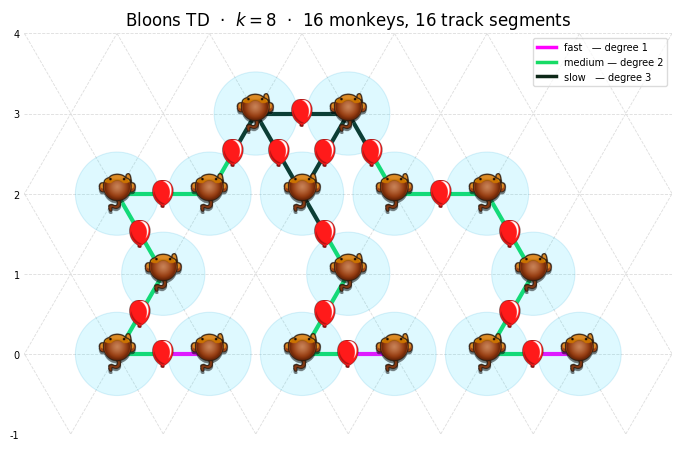

In [48]:
btd = mrp3sat_to_btd(mrp3sat_instance, positive_levels, negative_levels)

deg_dist = {d: sum(1 for v in btd.vertices if len(btd.adjacency[v]) == d)
            for d in (1, 2, 3)}
print(f"vertices : {len(btd.vertices)}")
print(f"edges    : {len(btd.edges)}")
print(f"k        : {btd.k}")
print(f"degree distribution: {deg_dist}")

# JSON round-trip check
btd_json = json.dumps(btd.to_dict(), indent=2)
print(f"JSON size: {len(btd_json)} bytes")

fig_btd_final, axis_btd_final = draw_btd_instance(btd)
plt.show()


## Yes-instance to Yes-instance

In [49]:
_CERT_TRUE_COLOUR  = "#2ecc71"   # green  — variable assigned true
_CERT_FALSE_COLOUR = "#e74c3c"   # red    — variable assigned false
_CERT_SAT_COLOUR   = "#f1c40f"   # gold   — the literal that satisfies a clause
_CERT_UNSAT_COLOUR = "#888888"   # gray   — unsatisfied clause (should not occur in yes-instance)

Certificate = dict[int, bool]   # variable index → True/False

In [50]:
def _clause_satisfied_by(
    clause: Clause,
    certificate: Certificate,
) -> list[int]:
    """
    Return which variables in this clause make it true under the certificate.
    For positive clauses: a variable satisfies it if it is true.
    For negative clauses: a variable satisfies it if it is false.
    """
    satisfying = []
    for v in clause.variables:
        v_true = certificate[v]
        if clause.sign == "positive" and v_true:
            satisfying.append(v)
        elif clause.sign == "negative" and not v_true:
            satisfying.append(v)
    return satisfying


def draw_instance_certificate(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels:  dict[str, int],
    negative_levels:  dict[str, int],
    certificate:      Certificate,
    output:           Path | str | None = None,
):
    x_start, width, pos_cx, neg_cx = compute_layout(
        mrp3sat_instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x = max(x_start[v] + width[v] for v in range(1, mrp3sat_instance.n + 1))

    fig_width  = max(7.0, total_x * 0.5)
    fig_height = max(4.5, (max_positive + max_negative + 2) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    # Variable boxes — coloured by truth assignment
    for v in range(1, mrp3sat_instance.n + 1):
        bx = x_start[v] - 0.4
        bw = width[v] - 1 + 0.8
        fill = _CERT_TRUE_COLOUR if certificate[v] else _CERT_FALSE_COLOUR
        axis.add_patch(FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor=fill, zorder=5,
        ))
        value_str = "T" if certificate[v] else "F"
        axis.text(
            bx + bw / 2, 0, f"x{v}={value_str}",
            ha="center", va="center", fontsize=8, zorder=6, fontweight="bold",
        )

    # Clause bars — per-literal colouring based on satisfaction
    for clauses, levels, direction, base_colour in [
        (mrp3sat_instance.positive, positive_levels,  1, _POS_COLOUR),
        (mrp3sat_instance.negative, negative_levels, -1, _NEG_COLOUR),
    ]:
        cx = pos_cx if direction == 1 else neg_cx
        for clause in clauses:
            y = direction * levels[clause.label]
            satisfying = _clause_satisfied_by(clause, certificate)
            clause_satisfied = len(satisfying) > 0
            xs = {v: cx[(clause.label, v)] for v in clause.variables}

            # Horizontal bar in base colour (or gray if unsatisfied)
            bar_colour = base_colour if clause_satisfied else _CERT_UNSAT_COLOUR
            axis.plot(
                [min(xs.values()), max(xs.values())], [y, y],
                color=bar_colour, linewidth=2.4,
            )

            y_root = direction * _BOX_H / 2
            for v in sorted(clause.variables):
                x = xs[v]
                # Highlight the specific literal(s) that satisfy the clause
                if v in satisfying:
                    edge_colour = _CERT_SAT_COLOUR
                    lw = 2.0
                else:
                    edge_colour = bar_colour
                    lw = 1.2
                axis.plot([x, x], [y_root, y], color=edge_colour, linewidth=lw, alpha=0.9)
                axis.scatter([x], [y], color=edge_colour, s=22, zorder=3)

            # Clause label — add ✓ or ✗
            label_y = y + 0.16 * direction
            va = "bottom" if direction > 0 else "top"
            tick  = " ✓" if clause_satisfied else " ✗"
            axis.text(
                (min(xs.values()) + max(xs.values())) / 2,
                label_y, clause.label + tick,
                ha="center", va=va, fontsize=10,
                color=bar_colour, fontweight="bold",
            )

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-1, total_x+1)
    axis.set_ylim(-(max_negative + 1), max_positive + 2)
    axis.set_xticks(range(total_x + 1))
    axis.set_yticks(range(-(max_negative + 1), max_positive + 2))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)

    # Legend
    for label, colour in [
        ("true",      _CERT_TRUE_COLOUR),
        ("false",     _CERT_FALSE_COLOUR),
        ("satisfies", _CERT_SAT_COLOUR),
        ("unsatisfied clause", _CERT_UNSAT_COLOUR),
    ]:
        axis.plot([], [], color=colour, linewidth=3, label=label)
    axis.legend(loc="upper right", fontsize=8, framealpha=0.8)

    axis.set_title("MRP3SAT Certificate Visualization")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved to {output}")

    return fig, axis

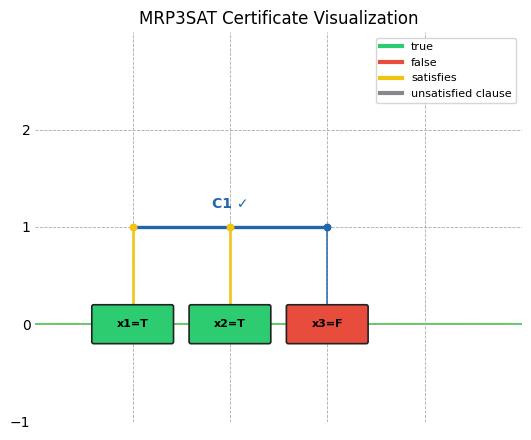

In [51]:
certificate: Certificate = CERT

fig_cert, axis_cert = draw_instance_certificate(
    mrp3sat_instance, positive_levels, negative_levels, certificate
)
plt.show()

In [ ]:
from collections import deque, defaultdict

# helper functions?

def _triangle_edges(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    pos_cx,
    neg_cx,
) -> set[frozenset[GridPoint]]:
    """
    Return exactly the three internal edges of every OR gadget.
    """

    result: set[frozenset[GridPoint]] = set()

    def _side(clauses, levels, connector_x, direction):
        for clause in clauses:
            level = levels[clause.label]

            _, M, _ = sorted(clause.variables)
            x_M = connector_x[(clause.label, M)]

            gy_bar = direction * 2 * level

            A = GridPoint(2 * x_M,     gy_bar)
            B = GridPoint(2 * x_M - 1, gy_bar + direction)
            C = GridPoint(2 * x_M + 1, gy_bar + direction)

            result.add(frozenset((A, B)))
            result.add(frozenset((A, C)))
            result.add(frozenset((B, C)))

    _side(
        mrp3sat_instance.positive,
        positive_levels,
        pos_cx,
        +1,
    )

    _side(
        mrp3sat_instance.negative,
        negative_levels,
        neg_cx,
        -1,
    )

    return result


In [ ]:
def _patch_variable_row(
    row_nodes: list[GridPoint],
    monkeys: set[GridPoint],
) -> None:
    """
    row_nodes must be left-to-right along a single variable row.

    Applies the 14-rule patching algorithm from the notebook notes.
    """

    s = ["M" if v in monkeys else "O" for v in row_nodes]

    processed = 0

    while processed < len(s):

        remaining = len(s) - processed

        #
        # Scenario 1
        #
        if remaining == 1:
            processed += 1
            continue

        a = s[processed]
        b = s[processed + 1]

        #
        # Scenario 2
        # OM
        #
        if a == "O" and b == "M":
            processed += 1
            continue

        #
        # Scenario 3
        # OO
        #
        if a == "O" and b == "O":

            #
            # Scenario 5
            # OO$
            #
            if remaining == 2:
                s[processed] = "M"
                processed += 2
                continue

            c = s[processed + 2]

            #
            # Scenario 4
            # OOM
            #
            if c == "M":
                s[processed] = "M"
                processed += 2
                continue

            #
            # Scenario 3
            # OO...
            #
            processed += 1
            continue

        #
        # Scenario 6
        # MM
        #
        if a == "M" and b == "M":
            processed += 1
            continue

        #
        # Scenario 7
        # M$
        #
        if a == "M" and remaining == 1:
            processed += 1
            continue

        #
        # Scenario 8+
        # MO...
        #
        if a == "M" and b == "O":

            #
            # Scenario 10
            # MO$
            #
            if remaining == 2:
                processed += 2
                continue

            c = s[processed + 2]

            #
            # Scenario 9
            # MOM
            #
            if c == "M":
                processed += 2
                continue

            #
            # Scenario 11+
            # MOO...
            #
            if remaining == 3:
                #
                # Scenario 13
                # MOO$
                #
                s[processed + 2] = "M"
                processed += 3
                continue

            d = s[processed + 3]

            #
            # Scenario 12
            # MOOM
            #
            if d == "M":
                s[processed + 2] = "M"
                processed += 3
                continue

            #
            # Scenario 14
            # MOOO
            #
            s[processed + 2] = "M"
            processed += 2
            continue

        raise RuntimeError(
            f"Unhandled variable-row pattern near index {processed}: "
            f'{"".join(s[max(0, processed-2):processed+6])}'
        )

    #
    # Write back into monkey set.
    #
    for node, ch in zip(row_nodes, s):
        if ch == "M":
            monkeys.add(node)
        else:
            monkeys.discard(node)

In [ ]:
# cert computation

def compute_certificate_monkey_set(
    mrp3sat_instance: MRP3SATInstance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    certificate: Certificate,
) -> set[GridPoint]:

    x_start, width, pos_cx, neg_cx = compute_layout_alternating(
        mrp3sat_instance,
        positive_levels,
        negative_levels,
    )

    raw_edges = _collect_btd_raw_edges(
        mrp3sat_instance,
        positive_levels,
        negative_levels,
        x_start,
        width,
        pos_cx,
        neg_cx,
    )

    triangle_edges = _triangle_edges(
        mrp3sat_instance,
        positive_levels,
        negative_levels,
        pos_cx,
        neg_cx,
    )

    #
    # Remove:
    #   (1) triangle edges
    #   (2) horizontal variable-row edges
    #
    adj: dict[GridPoint, set[GridPoint]] = defaultdict(set)

    for u, v in raw_edges:

        if frozenset((u, v)) in triangle_edges:
            continue

        if u.gy == 0 and v.gy == 0:
            continue

        adj[u].add(v)
        adj[v].add(u)

    monkeys: set[GridPoint] = set()
    visited: set[GridPoint] = set()

    def seed_clause(
        clause: Clause,
        level: int,
        connector_x,
        direction: int,
    ) -> None:

        vars_sorted = sorted(clause.variables)

        #
        # Choose the leftmost satisfying literal.
        #
        uncovered_var = None

        for var in vars_sorted:
            if direction > 0:
                if certificate[var]:
                    uncovered_var = var
                    break
            elif direction < 0:
                if not certificate[var]:
                    uncovered_var = var
                    break

        if uncovered_var is None:
            uncovered_var = vars_sorted[0]

        _, M, _ = vars_sorted
        x_M = connector_x[(clause.label, M)]

        gy_bar = direction * 2 * level

        A = GridPoint(2 * x_M,     gy_bar)
        B = GridPoint(2 * x_M - 1, gy_bar + direction)
        C = GridPoint(2 * x_M + 1, gy_bar + direction)

        corners = {
            vars_sorted[0]: B,
            vars_sorted[1]: A,
            vars_sorted[2]: C,
        }

        uncovered_corner = corners[uncovered_var]

        for corner in (A, B, C):

            start_has_monkey = (corner != uncovered_corner)

            q = deque([(corner, start_has_monkey)])

            while q:

                node, has_monkey = q.popleft()

                if node in visited:
                    continue

                visited.add(node)

                if has_monkey:
                    monkeys.add(node)

                #
                # Stop when we reach the variable row.
                #
                if node.gy == 0:
                    continue

                for nbr in adj[node]:
                    if nbr not in visited:
                        q.append((nbr, not has_monkey))

    for clause in mrp3sat_instance.positive:

        seed_clause(
            clause,
            positive_levels[clause.label],
            pos_cx,
            +1,
        )

    for clause in mrp3sat_instance.negative:

        seed_clause(
            clause,
            negative_levels[clause.label],
            neg_cx,
            -1,
        )

    #
    # Patch each variable row independently.
    #
    for var in range(1, mrp3sat_instance.n + 1):

        start = x_start[var]

        row_nodes = [
            GridPoint(2 * (start + offset), 0)
            for offset in range(width[var])
        ]

        _patch_variable_row(
            row_nodes,
            monkeys,
        )

    return monkeys

In [ ]:
# drawing the cert

def draw_btd_certificate(
    btd:        BtdInstance,
    monkey_set: set[GridPoint],
    output:     Path | str | None = None,
) -> tuple:
    """
    Render the BTD instance with certificate-driven monkey placements.
    Nodes in monkey_set get a dart monkey; all others get an empty circle.
    """
    def to_xy(gp: GridPoint) -> tuple[float, float]:
        return gp.gx * 0.5, gp.gy * _GRID_STEP

    def midpoint(e: BtdEdge) -> tuple[float, float]:
        return (
            (e.start.gx + e.end.gx) * 0.25,
            (e.start.gy + e.end.gy) * _GRID_STEP / 2,
        )

    gx_vals = [v.gx for v in btd.vertices]
    gy_vals = [v.gy for v in btd.vertices]
    k_min   = min(gy_vals) - 1
    k_max   = max(gy_vals) + 1
    x_min   = min(gx_vals) * 0.5 - 1.0
    x_max   = max(gx_vals) * 0.5 + 1.0
    y_bot   = k_min * _GRID_STEP
    y_top   = k_max * _GRID_STEP

    fig_width  = max(7.0, (x_max - x_min) * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max, color="#dddddd")

    speed_colour = {
        TrackSpeed.FAST:   _TRACK_FAST_COLOUR,
        TrackSpeed.MEDIUM: _TRACK_MED_COLOUR,
        TrackSpeed.SLOW:   _TRACK_SLOW_COLOUR,
    }
    for e in btd.edges:
        x1, y1 = to_xy(e.start)
        x2, y2 = to_xy(e.end)
        mx, my  = midpoint(e)
        axis.plot([x1, mx], [y1, my],
                  color=speed_colour[e.start_speed],
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")
        axis.plot([mx, x2], [my, y2],
                  color=speed_colour[e.end_speed],
                  linewidth=_TRACK_LINEWIDTH, zorder=1, solid_capstyle="butt")
        _draw_icon(axis, mx, my, _RED_BLOON_URL,_fallback_red_bloon, _ICON_HALF_BLOON,)

    n_placed = 0
    for v in btd.vertices:
        x, y = to_xy(v)
        if v in monkey_set:
            _draw_icon(axis, x, y, _DART_MONKEY_URL, _fallback_dart_monkey, _ICON_HALF_MONKEY)
            n_placed += 1
        else:
            axis.scatter([x], [y], s=_NODE_R_VAR,
                         facecolors="white", edgecolors="#999999",
                         linewidths=1.0, zorder=5)

    for label, colour in [
        ("fast   — degree 1", _TRACK_FAST_COLOUR),
        ("medium — degree 2", _TRACK_MED_COLOUR),
        ("slow   — degree 3", _TRACK_SLOW_COLOUR),
    ]:
        axis.plot([], [], color=colour, linewidth=2.5, label=label)
    axis.plot([], [], linestyle="none", marker="o",
              markerfacecolor="white", markeredgecolor="#999999",
              markersize=6, label="not in cover")
    axis.legend(loc="upper right", fontsize=7, framealpha=0.7)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top+1)
    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])
    axis.set_title(
        rf"BTD Certificate  ·  {n_placed}/{len(btd.vertices)} monkeys placed  ·  $k={btd.k}$"
    )
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()
    if output is not None:
        fig.savefig(Path(output), bbox_inches="tight")
    return fig, axis

In [ ]:
monkey_set = compute_certificate_monkey_set(
    mrp3sat_instance, positive_levels, negative_levels, certificate
)
print(f"Monkeys from certificate: {len(monkey_set)} / {len(btd.vertices)} nodes")

fig_cert_btd, axis_cert_btd = draw_btd_certificate(btd, monkey_set)
plt.show()

In [ ]:
def verify_vertex_cover(btd: BtdInstance, monkeys: set[GridPoint]) -> bool:
    return all(
        e.start in monkeys or e.end in monkeys
        for e in btd.edges
    )
is_valid_vc = verify_vertex_cover(btd, monkey_set)
if (is_valid_vc):
    print("yes, this is a vertex cover")
else:
    print("no, this is a vertex cover")

## Patching the variable row:

Let `M` = monkey, `O` = no monkey, `X` = monkey or no monkey, `$` = end of variable.
We will also need a pointer `^`. We only write down chars we've seen and not processed.
"Next" means read next char.

### Scenario 1:
**See:**
```
X
^
```
**Action:** Next

*note: there will always be a non-zero and even number of nodes to read per variable*

### Scenario 2:
**See:**
```
OM
 ^
```
**Action:** mark `str[0]` as processed. Next

### Scenario 3:
**See:**
```
OO
 ^
```
**Action:** Next


### Scenario 4:
**See:**
```
OOM
  ^
```
**Action:** set `str[0] = M` and mark `str[0..1]` as processed. Next

### Scenario 5:
**See:**
```
OO$
  ^
```
**Action:** set `str[0] = M` and mark `str[0..1]` as processed. Done

### Scenario 6:
**See:**
```
MM
 ^
```
**Action:** mark `str[0]` as processed. Next

### Scenario 7:
**See:**
```
M$
 ^
```
**Action:** mark `str[0]` as processed. Done

### Scenario 8:
**See:**
```
MO
 ^
```
**Action:** Next


### Scenario 9:
**See:**
```
MOM
  ^
```
**Action:** mark `str[0..1]` as processed. Next

### Scenario 10:
**See:**
```
MO$
  ^
```
**Action:** mark `str[0..1]` as processed. Done

### Scenario 11:
**See:**
```
MOO
  ^
```
**Action:** Next

### Scenario 12:
**See:**
```
MOOM
   ^
```
**Action:** set `str[2] = M` and mark `str[0..2]` as processed. Next

### Scenario 13:
**See:**
```
MOO$
   ^
```
**Action:** set `str[2] = M` and mark `str[0..2]` as processed. Done

### Scenario 14:
**See:**
```
MOOO
   ^
```
**Action:** set `str[2] = M` and mark `str[0..1]` as processed. Next
